In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "ml" / "data" / "porto_eta_sample.csv"

# Load the 30,000-trip sample
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (30000, 9)

Columns:
['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']


In [3]:
# Basic data quality checks

print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE TRIP IDs ===")
print(df["TRIP_ID"].duplicated().sum())

print("\n=== MISSING TRAJECTORIES ===")
print(df["POLYLINE"].isnull().sum())

print("\n=== MISSING DATA FLAG ===")
print(df["MISSING_DATA"].value_counts(dropna=False))

print("\n=== UNIQUE TAXIS ===")
print(df["TAXI_ID"].nunique())

=== DATA TYPES ===
TRIP_ID           int64
CALL_TYPE        object
ORIGIN_CALL     float64
ORIGIN_STAND    float64
TAXI_ID           int64
TIMESTAMP         int64
DAY_TYPE         object
MISSING_DATA       bool
POLYLINE         object
dtype: object

=== MISSING VALUES ===
TRIP_ID             0
CALL_TYPE           0
ORIGIN_CALL     23652
ORIGIN_STAND    15895
TAXI_ID             0
TIMESTAMP           0
DAY_TYPE            0
MISSING_DATA        0
POLYLINE            0
dtype: int64

=== DUPLICATE TRIP IDs ===
0

=== MISSING TRAJECTORIES ===
0

=== MISSING DATA FLAG ===
MISSING_DATA
False    30000
Name: count, dtype: int64

=== UNIQUE TAXIS ===
440


In [4]:
import ast
import math


GPS_INTERVAL_SECONDS = 15


def parse_polyline(polyline):
    """Convert a POLYLINE string into GPS coordinate pairs."""
    try:
        return ast.literal_eval(polyline)
    except (ValueError, SyntaxError, TypeError):
        return []


def haversine_distance(lon1, lat1, lon2, lat2):
    """Calculate distance between two GPS coordinates in km."""
    earth_radius_km = 6371.0

    lon1 = math.radians(lon1)
    lat1 = math.radians(lat1)
    lon2 = math.radians(lon2)
    lat2 = math.radians(lat2)

    delta_lon = lon2 - lon1
    delta_lat = lat2 - lat1

    a = (
        math.sin(delta_lat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(delta_lon / 2) ** 2
    )

    return 2 * earth_radius_km * math.atan2(
        math.sqrt(a),
        math.sqrt(1 - a)
    )


def calculate_route_features(polyline):
    """Extract route distance, duration and speed."""
    points = parse_polyline(polyline)

    if len(points) < 2:
        return pd.Series({
            "trip_duration_minutes": 0.0,
            "distance_km": 0.0,
            "average_speed_kmh": 0.0,
            "trajectory_points": len(points),
        })

    distance = 0.0

    for i in range(1, len(points)):
        previous = points[i - 1]
        current = points[i]

        distance += haversine_distance(
            previous[0],
            previous[1],
            current[0],
            current[1],
        )

    duration_minutes = (
        (len(points) - 1) * GPS_INTERVAL_SECONDS / 60
    )

    average_speed = (
        distance / (duration_minutes / 60)
        if duration_minutes > 0
        else 0
    )

    return pd.Series({
        "trip_duration_minutes": duration_minutes,
        "distance_km": distance,
        "average_speed_kmh": average_speed,
        "trajectory_points": len(points),
    })


# Apply route calculations
route_features = df["POLYLINE"].apply(calculate_route_features)

df = pd.concat([df, route_features], axis=1)

# Convert Unix timestamp to datetime
df["datetime"] = pd.to_datetime(df["TIMESTAMP"], unit="s")

df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("ETA variables created successfully!")
print()
print(
    df[
        [
            "TRIP_ID",
            "distance_km",
            "trip_duration_minutes",
            "average_speed_kmh",
            "trajectory_points",
            "hour",
            "day_of_week",
        ]
    ].head(10)
)

ETA variables created successfully!

               TRIP_ID  distance_km  trip_duration_minutes  average_speed_kmh  \
0  1377560292620000409     1.720256                   3.50          29.490104   
1  1378733467620000184    12.773876                  13.75          55.740549   
2  1397495585620000173     5.012458                  16.00          18.796719   
3  1391343649620000395     3.028803                   5.50          33.041483   
4  1386168857620000510    80.141632                  54.00          89.046258   
5  1392853800620000678     1.250449                   4.25          17.653402   
6  1393272045620000594     3.020505                   7.25          24.997284   
7  1376405061620000267     4.815189                  10.75          26.875475   
8  1395436282620000010     8.399482                  12.00          41.997410   
9  1395134151620000608     1.819028                   9.25          11.799098   

   trajectory_points  hour  day_of_week  
0               15.0    23   

In [5]:
# Statistical overview of derived ETA variables

eta_columns = [
    "trip_duration_minutes",
    "distance_km",
    "average_speed_kmh",
    "trajectory_points",
    "hour",
    "day_of_week",
]

print("=== DESCRIPTIVE STATISTICS ===")
display(df[eta_columns].describe().round(2))

print("\n=== EXTREME VALUES ===")

for column in [
    "trip_duration_minutes",
    "distance_km",
    "average_speed_kmh",
]:
    print(f"\n{column}")
    print(f"Minimum : {df[column].min():.2f}")
    print(f"Maximum : {df[column].max():.2f}")
    print(f"Median  : {df[column].median():.2f}")

=== DESCRIPTIVE STATISTICS ===


,trip_duration_minutes,distance_km,average_speed_kmh,trajectory_points,hour,day_of_week
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,11.93,5.50,26.89,48.70,11.92,3.06
std,10.95,7.76,17.49,43.81,6.23,1.96
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.75,2.36,17.59,28.00,7.00,1.00
50%,10.00,3.93,23.55,41.00,12.00,3.00
75%,14.50,6.48,32.48,59.00,17.00,5.00
max,337.00,635.26,1232.11,1349.00,23.00,6.00



=== EXTREME VALUES ===

trip_duration_minutes
Minimum : 0.00
Maximum : 337.00
Median  : 10.00

distance_km
Minimum : 0.00
Maximum : 635.26
Median  : 3.93

average_speed_kmh
Minimum : 0.00
Maximum : 1232.11
Median  : 23.55


In [6]:
# Identify potentially unrealistic trips

print("=== POTENTIALLY INVALID TRIPS ===")

checks = {
    "Zero duration": df["trip_duration_minutes"] <= 0,
    "Zero distance": df["distance_km"] <= 0,
    "Speed > 120 km/h": df["average_speed_kmh"] > 120,
    "Speed > 200 km/h": df["average_speed_kmh"] > 200,
    "Distance > 100 km": df["distance_km"] > 100,
    "Duration > 180 min": df["trip_duration_minutes"] > 180,
}

for name, condition in checks.items():
    print(f"{name:25s}: {condition.sum():,}")

=== POTENTIALLY INVALID TRIPS ===
Zero duration            : 616
Zero distance            : 618
Speed > 120 km/h         : 51
Speed > 200 km/h         : 12
Distance > 100 km        : 22
Duration > 180 min       : 17


In [7]:
# Show the most extreme speed observations

print("=== TOP 10 HIGHEST SPEEDS ===")

display(
    df[
        [
            "TRIP_ID",
            "distance_km",
            "trip_duration_minutes",
            "average_speed_kmh",
            "trajectory_points",
            "hour",
        ]
    ]
    .sort_values("average_speed_kmh", ascending=False)
    .head(10)
)

=== TOP 10 HIGHEST SPEEDS ===


,TRIP_ID,distance_km,trip_duration_minutes,average_speed_kmh,trajectory_points,hour
4026,1377690604620000310,5.133773,0.25,1232.105535,2.0,11
6389,1378852280620000503,3.987941,0.50,478.552918,3.0,22
25256,1384670205620000492,3.785486,0.50,454.258269,3.0,6
17012,1373312342620000010,4.124138,0.75,329.931079,4.0,19
5788,1391124590620000409,2.637620,0.50,316.514446,3.0,23
11449,1383375041620000463,1.297745,0.25,311.458742,2.0,6
22210,1401639862620000525,1.284464,0.25,308.271446,2.0,16
26829,1379679222620000144,7.267716,1.50,290.708633,7.0,12
29542,1397936285620000158,2.093728,0.50,251.247341,3.0,19
29387,1381331250620000285,3.125662,0.75,250.052982,4.0,15


In [8]:
# Clean unrealistic GPS-derived trips

clean_df = df[
    (df["trajectory_points"] >= 5)
    & (df["distance_km"] > 0)
    & (df["trip_duration_minutes"] > 0)
    & (df["average_speed_kmh"] <= 120)
].copy()

clean_df = clean_df.reset_index(drop=True)

print("=== CLEANING RESULTS ===")
print(f"Original trips : {len(df):,}")
print(f"Clean trips    : {len(clean_df):,}")
print(f"Removed        : {len(df) - len(clean_df):,}")
print(f"Retention      : {len(clean_df) / len(df) * 100:.2f}%")

print("\n=== CLEAN DATA RANGE ===")
print(
    clean_df[
        [
            "trip_duration_minutes",
            "distance_km",
            "average_speed_kmh",
        ]
    ].describe().round(2)
)

=== CLEANING RESULTS ===
Original trips : 30,000
Clean trips    : 29,074
Removed        : 926
Retention      : 96.91%

=== CLEAN DATA RANGE ===
       trip_duration_minutes  distance_km  average_speed_kmh
count               29074.00     29074.00           29074.00
mean                   12.28         5.62              27.22
std                    10.83         6.60              13.80
min                     1.00         0.00               0.14
25%                     7.00         2.49              18.03
50%                    10.25         4.03              23.82
75%                    14.75         6.59              32.72
max                   337.00       266.66             119.81


In [9]:
# Refine cleaning for meaningful ETA observations

final_df = clean_df[
    (clean_df["distance_km"] >= 0.1)
    & (clean_df["trip_duration_minutes"] >= 1.0)
    & (clean_df["trip_duration_minutes"] <= 180)
].copy()

final_df = final_df.reset_index(drop=True)

print("=== FINAL ETA DATASET ===")
print(f"Original sample : {len(df):,}")
print(f"After first clean: {len(clean_df):,}")
print(f"Final clean data: {len(final_df):,}")
print(f"Total removed   : {len(df) - len(final_df):,}")
print(f"Retention       : {len(final_df) / len(df) * 100:.2f}%")

print("\n=== FINAL RANGES ===")
display(
    final_df[
        [
            "trip_duration_minutes",
            "distance_km",
            "average_speed_kmh",
        ]
    ].describe().round(2)
)

=== FINAL ETA DATASET ===
Original sample : 30,000
After first clean: 29,074
Final clean data: 28,964
Total removed   : 1,036
Retention       : 96.55%

=== FINAL RANGES ===


,trip_duration_minutes,distance_km,average_speed_kmh
count,28964.00,28964.00,28964.00
mean,12.19,5.60,27.31
std,9.49,6.22,13.74
min,1.00,0.10,0.35
25%,7.00,2.50,18.10
50%,10.25,4.03,23.86
75%,14.75,6.60,32.78
max,179.00,266.66,119.81


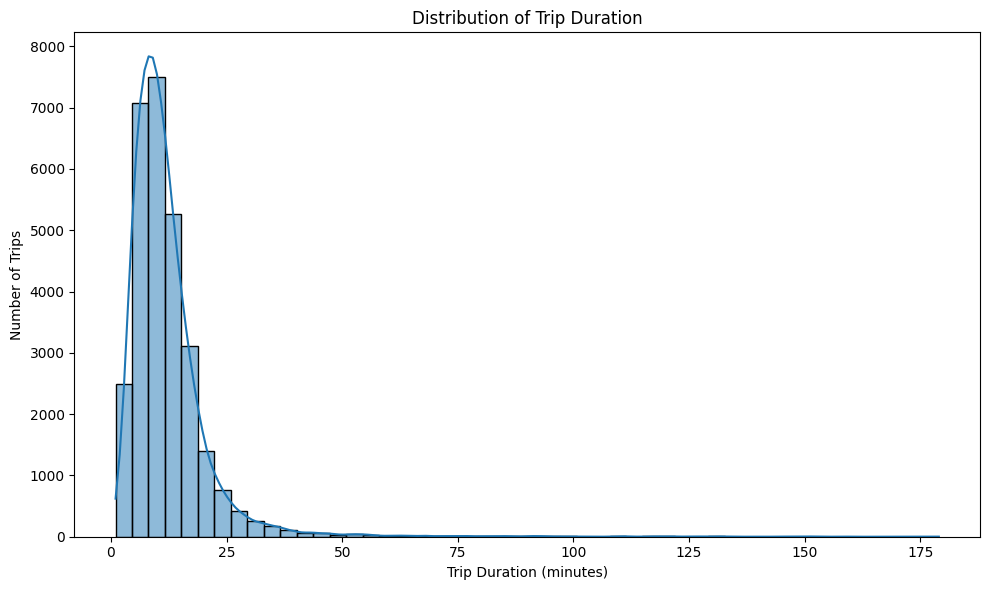

In [10]:
# Trip duration distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    final_df["trip_duration_minutes"],
    bins=50,
    kde=True
)

plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

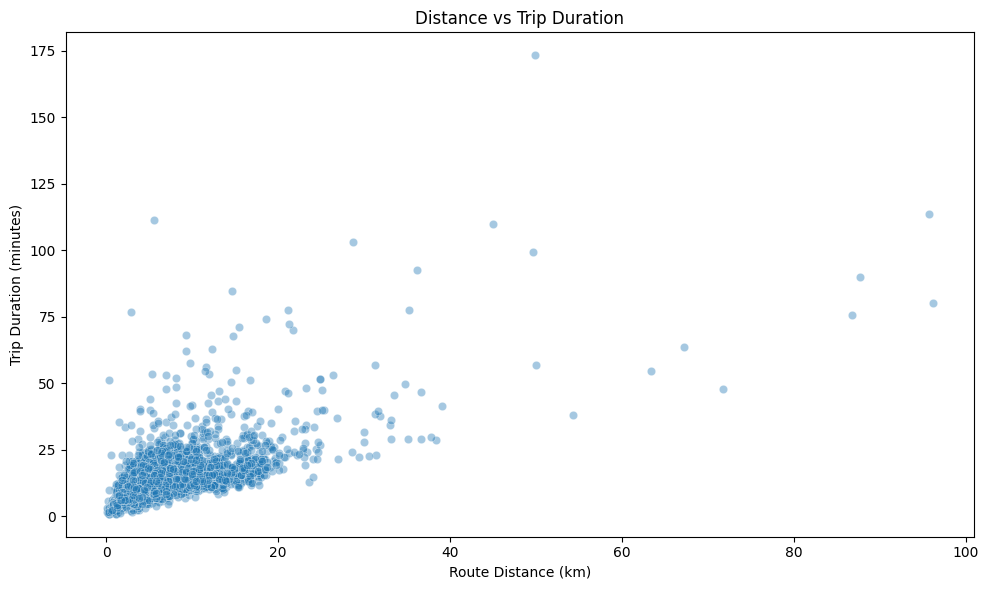

In [11]:
# Distance vs trip duration

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df.sample(
        min(5000, len(final_df)),
        random_state=42
    ),
    x="distance_km",
    y="trip_duration_minutes",
    alpha=0.4
)

plt.title("Distance vs Trip Duration")
plt.xlabel("Route Distance (km)")
plt.ylabel("Trip Duration (minutes)")
plt.tight_layout()
plt.show()

,count,mean,median
hour,,,
0,853,9.98,8.75
1,805,10.33,9.00
2,795,10.18,9.00
3,929,10.59,9.25
4,1040,10.76,9.50
5,892,10.54,9.75
6,887,11.57,9.75
7,1199,12.46,10.50
8,1594,12.96,11.00


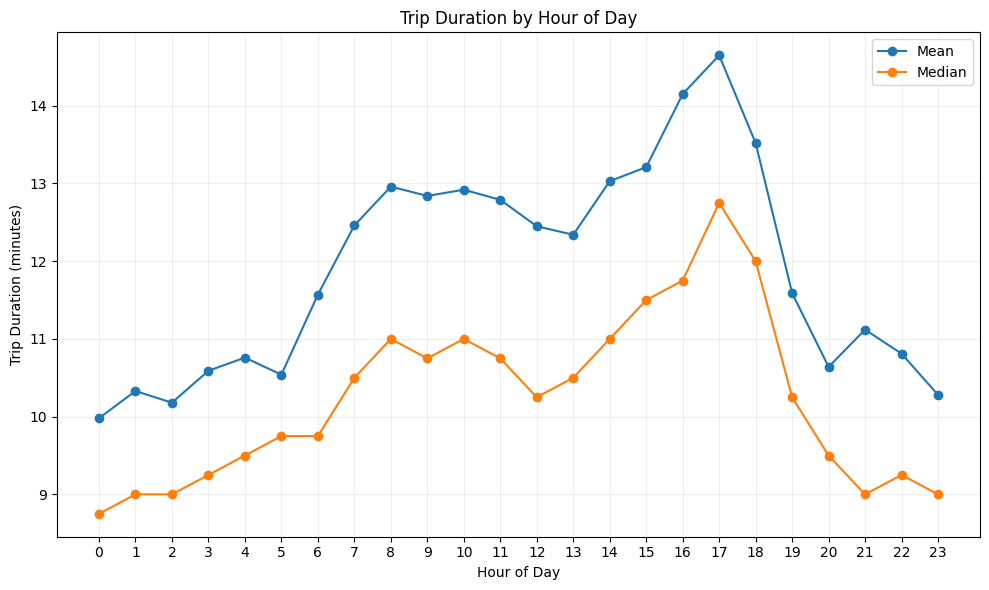

In [12]:
# Average trip duration by hour

hour_summary = (
    final_df
    .groupby("hour")["trip_duration_minutes"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(hour_summary)

plt.figure(figsize=(10, 6))

plt.plot(
    hour_summary.index,
    hour_summary["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    hour_summary.index,
    hour_summary["median"],
    marker="o",
    label="Median"
)

plt.title("Trip Duration by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Duration (minutes)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# Leakage-safe route features
#
# We calculate straight-line distance between the first and
# final GPS coordinates. Unlike completed route distance,
# this does not depend on the path taken during the trip.

def extract_start_end_coordinates(polyline):
    points = parse_polyline(polyline)

    if len(points) < 2:
        return pd.Series({
            "start_longitude": np.nan,
            "start_latitude": np.nan,
            "end_longitude": np.nan,
            "end_latitude": np.nan,
        })

    return pd.Series({
        "start_longitude": points[0][0],
        "start_latitude": points[0][1],
        "end_longitude": points[-1][0],
        "end_latitude": points[-1][1],
    })


coordinates = df["POLYLINE"].apply(extract_start_end_coordinates)

df = pd.concat([df, coordinates], axis=1)

df["straight_line_distance_km"] = df.apply(
    lambda row: haversine_distance(
        row["start_longitude"],
        row["start_latitude"],
        row["end_longitude"],
        row["end_latitude"],
    )
    if pd.notna(row["start_longitude"])
    else np.nan,
    axis=1,
)

print("Leakage-safe route features created!")

display(
    df[
        [
            "TRIP_ID",
            "start_longitude",
            "start_latitude",
            "end_longitude",
            "end_latitude",
            "straight_line_distance_km",
            "trip_duration_minutes",
        ]
    ].head(10)
)

Leakage-safe route features created!


,TRIP_ID,start_longitude,start_latitude,end_longitude,end_latitude,straight_line_distance_km,trip_duration_minutes
0,1377560292620000409,-8.638407,41.170815,-8.638164,41.159646,1.242103,3.50
1,1378733467620000184,-8.649585,41.154102,-8.670303,41.237811,9.468056,13.75
2,1397495585620000173,-8.606961,41.150142,-8.580447,41.178510,3.856975,16.00
3,1391343649620000395,-8.654787,41.153337,-8.627346,41.157522,2.344062,5.50
4,1386168857620000510,-8.585694,41.148891,-8.821026,41.695749,63.895258,54.00
5,1392853800620000678,-8.584407,41.163084,-8.589195,41.157270,0.760665,4.25
6,1393272045620000594,-8.673786,41.149584,-8.644059,41.154552,2.549489,7.25
7,1376405061620000267,-8.605152,41.184243,-8.630406,41.158107,3.593618,10.75
8,1395436282620000010,-8.607123,41.150286,-8.568576,41.193225,5.762512,12.00
9,1395134151620000608,-8.607060,41.146299,-8.613828,41.140269,0.877932,9.25


In [14]:
# Compare route distance measures

comparison = df[
    (df["distance_km"] > 0)
    & (df["straight_line_distance_km"] > 0)
].copy()

comparison["route_efficiency"] = (
    comparison["straight_line_distance_km"]
    / comparison["distance_km"]
)

print("=== DISTANCE COMPARISON ===")

display(
    comparison[
        [
            "distance_km",
            "straight_line_distance_km",
            "route_efficiency",
        ]
    ].describe().round(3)
)

print(
    "\nMedian route efficiency:",
    comparison["route_efficiency"].median().round(3)
)

=== DISTANCE COMPARISON ===


,distance_km,straight_line_distance_km,route_efficiency
count,29382.000,29382.000,29382.000
mean,5.616,3.388,0.655
std,7.795,3.919,0.190
min,0.001,0.001,0.000
25%,2.454,1.523,0.575
50%,3.996,2.607,0.692
75%,6.560,4.178,0.782
max,635.263,274.624,1.000



Median route efficiency: 0.692


In [15]:
# Build the final ETA modeling dataset

model_df = df[
    (df["trajectory_points"] >= 5)
    & (df["distance_km"] > 0)
    & (df["trip_duration_minutes"] >= 1.0)
    & (df["trip_duration_minutes"] <= 180)
    & (df["average_speed_kmh"] <= 120)
    & (df["straight_line_distance_km"] >= 0.1)
].copy()

model_df = model_df.reset_index(drop=True)

# Remove observations where the reconstructed coordinates are unavailable
model_df = model_df.dropna(
    subset=[
        "start_longitude",
        "start_latitude",
        "end_longitude",
        "end_latitude",
        "straight_line_distance_km",
    ]
).reset_index(drop=True)

print("=== ETA MODELING DATASET ===")
print(f"Rows: {len(model_df):,}")
print(f"Columns: {len(model_df.columns)}")

print("\n=== TARGET ===")
print("Target: trip_duration_minutes")

print("\n=== AVAILABLE PREDICTOR CANDIDATES ===")
print([
    "straight_line_distance_km",
    "start_longitude",
    "start_latitude",
    "end_longitude",
    "end_latitude",
    "hour",
    "day_of_week",
    "is_weekend",
    "CALL_TYPE",
    "ORIGIN_CALL",
    "ORIGIN_STAND",
])

print("\n=== TARGET STATISTICS ===")
display(
    model_df["trip_duration_minutes"]
    .describe()
    .round(2)
)

=== ETA MODELING DATASET ===
Rows: 28,636
Columns: 23

=== TARGET ===
Target: trip_duration_minutes

=== AVAILABLE PREDICTOR CANDIDATES ===
['straight_line_distance_km', 'start_longitude', 'start_latitude', 'end_longitude', 'end_latitude', 'hour', 'day_of_week', 'is_weekend', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND']

=== TARGET STATISTICS ===


count    28636.00
mean        12.04
std          9.08
min          1.00
25%          7.00
50%         10.25
75%         14.50
max        179.00
Name: trip_duration_minutes, dtype: float64

In [16]:
# Check route-efficiency anomalies

model_df["route_efficiency"] = (
    model_df["straight_line_distance_km"]
    / model_df["distance_km"]
)

print("=== ROUTE EFFICIENCY CHECK ===")

print(
    "Efficiency < 0.1:",
    (model_df["route_efficiency"] < 0.1).sum()
)

print(
    "Efficiency > 1.0:",
    (model_df["route_efficiency"] > 1.0).sum()
)

print("\n=== ROUTE EFFICIENCY STATISTICS ===")

display(
    model_df["route_efficiency"]
    .describe()
    .round(3)
)

=== ROUTE EFFICIENCY CHECK ===
Efficiency < 0.1: 387
Efficiency > 1.0: 0

=== ROUTE EFFICIENCY STATISTICS ===


count    28636.000
mean         0.661
std          0.174
min          0.001
25%          0.580
50%          0.693
75%          0.781
max          1.000
Name: route_efficiency, dtype: float64

In [17]:
# Create the leakage-safe ETA modeling table

feature_columns = [
    "TRIP_ID",
    "TIMESTAMP",
    "trip_duration_minutes",
    "straight_line_distance_km",
    "start_longitude",
    "start_latitude",
    "end_longitude",
    "end_latitude",
    "hour",
    "day_of_week",
    "is_weekend",
    "CALL_TYPE",
    "ORIGIN_CALL",
    "ORIGIN_STAND",
]

eta_model_data = model_df[feature_columns].copy()

output_path = PROJECT_ROOT / "ml" / "data" / "eta_model_data.csv"

eta_model_data.to_csv(output_path, index=False)

print("ETA modeling dataset saved!")
print(f"Path: {output_path}")
print(f"Rows: {len(eta_model_data):,}")
print(f"Columns: {len(eta_model_data.columns)}")

display(eta_model_data.head())

ETA modeling dataset saved!
Path: C:\Users\devra\OneDrive\Desktop\Devraj_coding\MissionFlow-AI\ml\data\eta_model_data.csv
Rows: 28,636
Columns: 14


,TRIP_ID,TIMESTAMP,trip_duration_minutes,straight_line_distance_km,start_longitude,start_latitude,end_longitude,end_latitude,hour,day_of_week,is_weekend,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND
0,1377560292620000409,1377560292,3.50,1.242103,-8.638407,41.170815,-8.638164,41.159646,23,0,0,A,30599.0,NaN
1,1378733467620000184,1378733467,13.75,9.468056,-8.649585,41.154102,-8.670303,41.237811,13,0,0,B,NaN,36.0
2,1397495585620000173,1397495585,16.00,3.856975,-8.606961,41.150142,-8.580447,41.178510,17,0,0,B,NaN,10.0
3,1391343649620000395,1391343649,5.50,2.344062,-8.654787,41.153337,-8.627346,41.157522,12,6,1,A,37266.0,NaN
4,1386168857620000510,1386168857,54.00,63.895258,-8.585694,41.148891,-8.821026,41.695749,14,2,0,B,NaN,NaN
